# Survey v1.1 — Visualisations
Plots covering four areas: **Measure Types**, **Building Characteristics**, **Sociodemographics**, and **Triggers & Subsidies**.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 1 · Measure Types

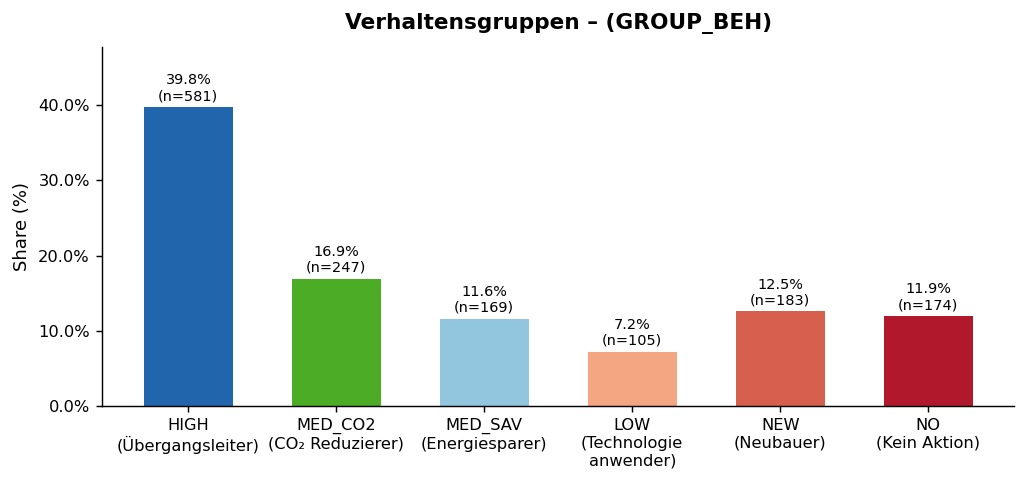

In [8]:
# ── 1b: Behavioural groups (GROUP_BEH) ────────────────────────────────────────
group_labels = {
    "1": "HIGH\n(Übergangsleiter)",
    "2": "MED_CO2\n(CO₂ Reduzierer)",
    "3": "MED_SAV\n(Energiesparer)",
    "4": "LOW\n(Technologie\nanwender)",
    "5": "NEW\n(Neubauer)",
    "6": "NO\n(Kein Aktion)",
}

grp_raw    = get_field("GROUP_BEH")
grp_counts = Counter(grp_raw)
keys       = sorted(grp_counts, key=int)
labels     = [group_labels[k] for k in keys]
counts     = [grp_counts[k] for k in keys]
pcts       = pct_of(counts)

colors_grp = ["#2166ac", "#4dac26", "#92c5de", "#f4a582", "#d6604d", "#b2182b"]

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(labels, pcts, color=colors_grp, width=0.6)
ax.set_title("Verhaltensgruppen – (GROUP_BEH)", pad=10)
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(pcts) * 1.2)
for bar, pct, cnt in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{pct:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()